In [ ]:
import pandas as pd
import numpy as np
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import imblearn.over_sampling as ios

# Load dataset (assuming a CSV file)
path = kagglehub.dataset_download("uom190346a/ai-powered-job-market-insights")

print("Path to dataset files:", path)
df = pd.read_csv("ai_job_market_insights.csv")

# Drop rows with missing values
df.dropna(inplace=True)

from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


# Encode categorical variables
label_encoders = {}
categorical_columns = ["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target variable
X = df[["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]]
y = df["Automation_Risk"]

# Encode target variable
y = LabelEncoder().fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/uom190346a/ai-powered-job-market-insights/versions/1
Accuracy: 0.28
Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.33      0.30        33
           1       0.36      0.31      0.33        32
           2       0.22      0.20      0.21        35

    accuracy                           0.28       100
   macro avg       0.28      0.28      0.28       100
weighted avg       0.28      0.28      0.28       100

Confusion Matrix:
 [[11 10 12]
 [ 9 10 13]
 [20  8  7]]


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

# Load dataset (assuming a CSV file)
path = kagglehub.dataset_download("uom190346a/ai-powered-job-market-insights")

print("Path to dataset files:", path)
df = pd.read_csv("ai_job_market_insights.csv")

# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical variables
label_encoders = {}
categorical_columns = ["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target variable
X = df[["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]]
y = df["Automation_Risk"]

# Encode target variable
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)
label_mapping = dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_)))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Hyperparameter tuning with GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Train optimized Random Forest Classifier
best_params = grid_search.best_params_
clf = RandomForestClassifier(**best_params, random_state=42)
clf.fit(X_train, y_train)

# Make predictions
y_pred = clf.predict(X_test)

# Convert numeric predictions back to labels
y_test_labels = [y_encoder.inverse_transform([label])[0] for label in y_test]
y_pred_labels = [y_encoder.inverse_transform([label])[0] for label in y_pred]

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/uom190346a/ai-powered-job-market-insights/versions/1
Accuracy: 0.28
Classification Report:
               precision    recall  f1-score   support

        High       0.27      0.29      0.28        34
         Low       0.30      0.29      0.30        31
      Medium       0.27      0.26      0.26        35

    accuracy                           0.28       100
   macro avg       0.28      0.28      0.28       100
weighted avg       0.28      0.28      0.28       100

Confusion Matrix:
 [[10 10 14]
 [12  9 10]
 [15 11  9]]


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/uom190346a/ai-powered-job-market-insights/versions/1


/home/codespace/.python/current/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:30:58] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Accuracy: 0.32
Classification Report:
               precision    recall  f1-score   support

        High       0.29      0.29      0.29        34
         Low       0.30      0.23      0.26        31
      Medium       0.36      0.43      0.39        35

    accuracy                           0.32       100
   macro avg       0.32      0.32      0.31       100
weighted avg       0.32      0.32      0.32       100

Confusion Matrix:
 [[10 11 13]
 [10  7 14]
 [15  5 15]]


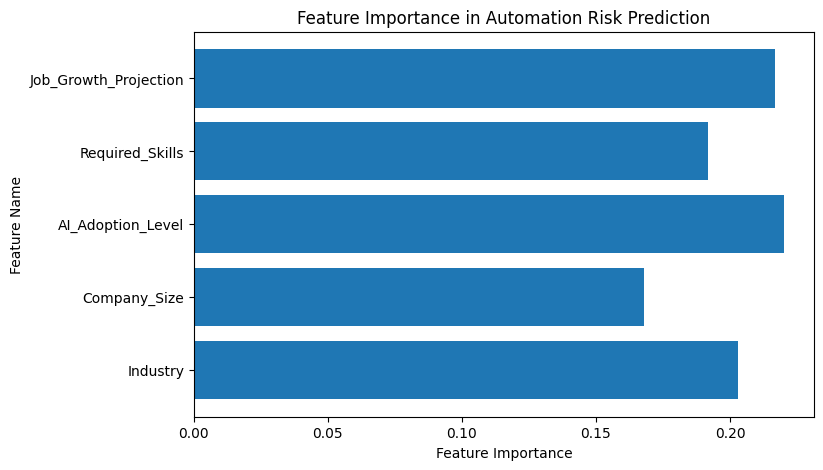

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

# Load dataset (assuming a CSV file)
path = kagglehub.dataset_download("uom190346a/ai-powered-job-market-insights")

print("Path to dataset files:", path)
df = pd.read_csv("ai_job_market_insights.csv")

# Drop rows with missing values
df.dropna(inplace=True)

# Encode categorical variables
label_encoders = {}
categorical_columns = ["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Define features and target variable
X = df[["Industry", "Company_Size", "AI_Adoption_Level", "Required_Skills", "Job_Growth_Projection"]]
y = df["Automation_Risk"]

# Encode target variable
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)
label_mapping = dict(zip(y_encoder.classes_, y_encoder.transform(y_encoder.classes_)))

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Apply SMOTE to balance the classes
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# Feature scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train XGBoost Classifier
xgb_clf = XGBClassifier(use_label_encoder=False, eval_metric="mlogloss")
xgb_clf.fit(X_train, y_train)

# Make predictions
y_pred = xgb_clf.predict(X_test)

# Convert numeric predictions back to labels
y_test_labels = [y_encoder.inverse_transform([label])[0] for label in y_test]
y_pred_labels = [y_encoder.inverse_transform([label])[0] for label in y_pred]

# Evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print("XGBoost Accuracy:", accuracy)
print("Classification Report:\n", classification_report(y_test_labels, y_pred_labels))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Feature Importance
feature_importances = xgb_clf.feature_importances_
feature_names = X.columns

plt.figure(figsize=(8, 5))
plt.barh(feature_names, feature_importances)
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Automation Risk Prediction")
plt.show()


In [2]:
import pandas as pd
path = '../input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv'
df = pd.read_csv(path)

FileNotFoundError: [Errno 2] No such file or directory: '../input/default-of-credit-card-clients-dataset/UCI_Credit_Card.csv'